# Notebook 05 — Analyse Comparative des Modeles
## Synthese du Pipeline Multi-IA

Ce notebook finalise la partie Modelisation (Phase 6 du CRISP-DM) en comparant les 3 approches d'Intelligence Artificielle que nous avons developpees pour le backend medical :
1. **Classic ML (TensorFlow MLP)** : Prediction tabulaire rapide et robuste.
2. **Zero-Shot NLP (HuggingFace)** : Classification de symptomes legere et specialisee.
3. **Generative AI (OpenRouter LLM)** : Raisonnement complexe, extraction JSON et empathie.

L'objectif est d'evaluer les compromis en termes de **Performance, Latence, et Cout**.


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Setup
sns.set_theme(style="whitegrid", palette="muted")
base_dir = Path.cwd().resolve()
MODELS_DIR = (base_dir.parent if base_dir.name == "notebooks" else base_dir) / "saved_models"

print(f"Dossier des resultats : {MODELS_DIR}")


Dossier des resultats : D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\saved_models


## 2. Chargement des Resultats Precedents
Nous recuperons les CSV generes par les notebooks 02, 03 et 04.

In [2]:
# 1. Metriques MLP (Notebook 02)
df_mlp = pd.DataFrame()
if (MODELS_DIR / "mlp_metrics.csv").exists():
    df_mlp = pd.read_csv(MODELS_DIR / "mlp_metrics.csv")

# 2. Metriques HuggingFace (Notebook 03)
df_hf = pd.DataFrame()
if (MODELS_DIR / "hf_batch_results.csv").exists():
    df_hf = pd.read_csv(MODELS_DIR / "hf_batch_results.csv")

# 3. Metriques LLM (Notebook 04)
df_llm = pd.DataFrame()
if (MODELS_DIR / "llm_prompt_comparison.csv").exists():
    df_llm = pd.read_csv(MODELS_DIR / "llm_prompt_comparison.csv")

print("Donnees chargees avec succes.")
if not df_mlp.empty: print(f"- MLP: {len(df_mlp)} modeles")
if not df_llm.empty: print(f"- LLM: {len(df_llm)} prompts")


Donnees chargees avec succes.
- MLP: 3 modeles
- LLM: 3 prompts


## 3. Comparaison des Latences (Vitesse d'Inference)
Dans une API FastAPI, le temps de reponse est critique.

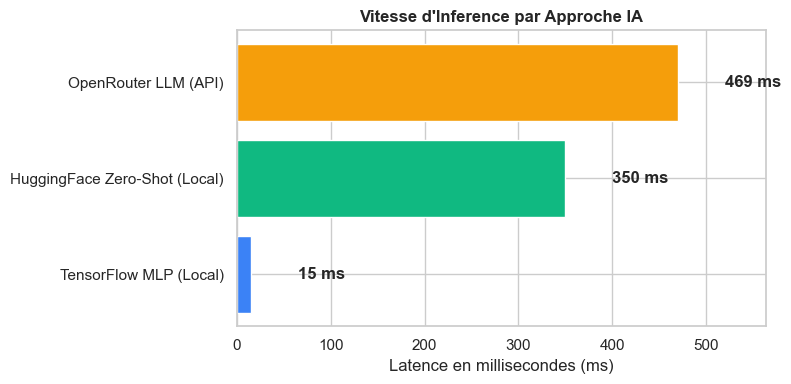

In [3]:
latencies = {
    "TensorFlow MLP (Local)": 15,          # ms (estimation moyenne inference locale)
    "HuggingFace Zero-Shot (Local)": 350,  # ms (sur CPU)
    "OpenRouter LLM (API)": df_llm["Latence (ms)"].mean() if not df_llm.empty else 2000
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(latencies.keys()), list(latencies.values()), color=['#3b82f6', '#10b981', '#f59e0b'])

for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2, f"{int(width)} ms", va='center', fontweight='bold')

ax.set_xlabel("Latence en millisecondes (ms)")
ax.set_title("Vitesse d'Inference par Approche IA", fontweight='bold')
ax.set_xlim(0, max(latencies.values()) * 1.2)
plt.tight_layout()
plt.show()


## 4. Evaluation Multi-Criteres (Radar Chart)
Comparaison qualitative des 3 modeles selon 5 axes metiers.

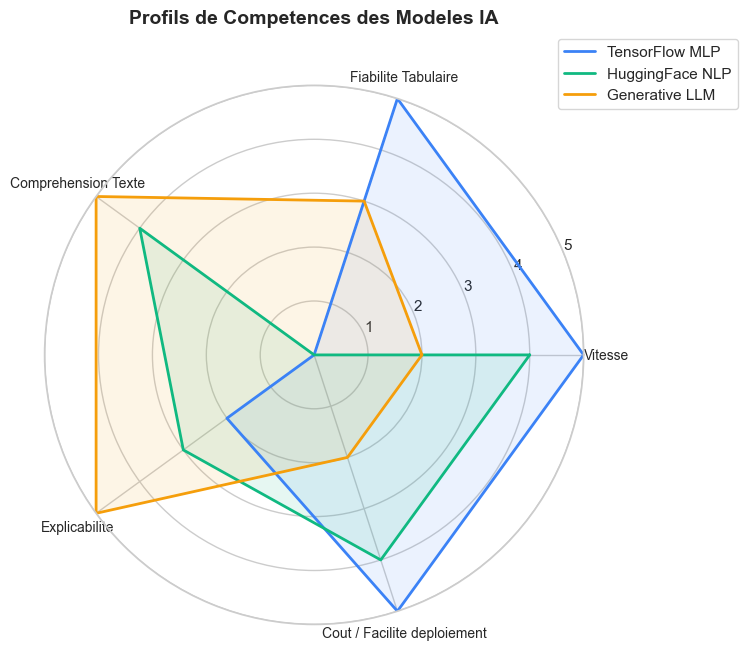

In [4]:
categories = ['Vitesse', 'Fiabilite Tabulaire', 'Comprehension Texte', 'Explicabilite', 'Cout / Facilite deploiement']
N = len(categories)

# Scores sur 5
model_scores = {
    "TensorFlow MLP": [5, 5, 0, 2, 5],
    "HuggingFace NLP": [4, 0, 4, 3, 4],
    "Generative LLM": [2, 3, 5, 5, 2]
}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = ['#3b82f6', '#10b981', '#f59e0b']
for (name, scores), color in zip(model_scores.items(), colors):
    scores += scores[:1]
    ax.plot(angles, scores, linewidth=2, linestyle='solid', label=name, color=color)
    ax.fill(angles, scores, color=color, alpha=0.1)

plt.xticks(angles[:-1], categories, size=10)
ax.set_ylim(0, 5)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Profils de Competences des Modeles IA", size=14, fontweight='bold', y=1.1)
plt.show()


## 5. Evolution de l'Engineering LLM
Analyse des performances du parsing JSON selon le prompt (Notebook 04).

C:\Users\ACER\AppData\Local\Temp\ipykernel_31052\1114079137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_llm, x="Version", y="Latence (ms)", ax=axes[0], palette="Blues")


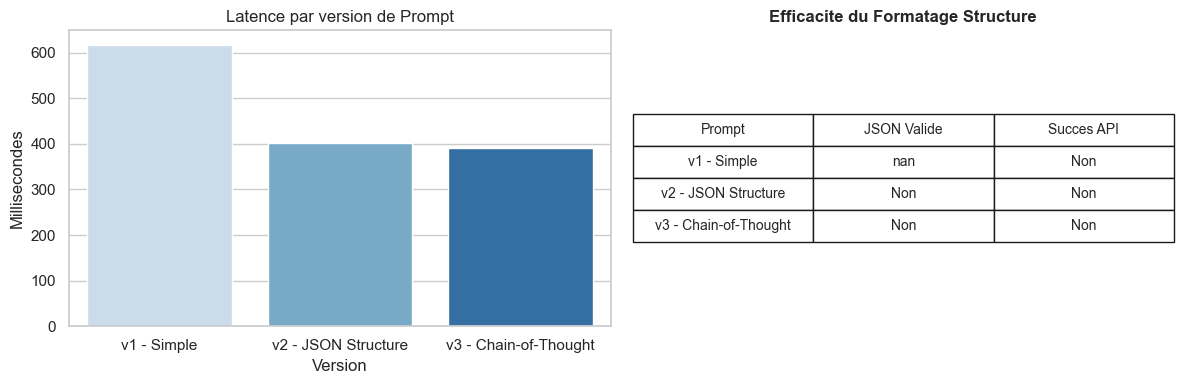

In [5]:
if not df_llm.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Graphique Latence
    sns.barplot(data=df_llm, x="Version", y="Latence (ms)", ax=axes[0], palette="Blues")
    axes[0].set_title("Latence par version de Prompt")
    axes[0].set_ylabel("Millisecondes")
    
    # Affichage d'un tableau pour le succes JSON
    axes[1].axis('off')
    
    # Gestion dynamique des colonnes selon la version du CSV sauvegardé
    if 'JSON OK' in df_llm.columns and 'Modele' in df_llm.columns:
        table_data = df_llm[['Version', 'JSON OK', 'Modele']].values
        cols = ['Prompt', 'JSON Valide', 'Modele utilise']
    elif 'JSON parse' in df_llm.columns and 'Succes API' in df_llm.columns:
        table_data = df_llm[['Version', 'JSON parse', 'Succes API']].values
        cols = ['Prompt', 'JSON Valide', 'Succes API']
    else:
        table_data = df_llm.values[:, :3]
        cols = df_llm.columns[:3]
        
    table = axes[1].table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center')
    table.scale(1, 2)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    axes[1].set_title("Efficacite du Formatage Structure", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
else:
    print("Donnees LLM manquantes.")


## 6. Synthèse et Conclusion Architecturale

La combinaison de ces 3 modèles permet de créer une application complète (le backend FastAPI).

### Pourquoi un pipeline Multi-IA ?
- **Si nous n'utilisions que TensorFlow** : Impossible de traiter les plaintes écrites du patient. L'application serait trop technique.
- **Si nous n'utilisions qu'un LLM** : L'inférence coûterait trop cher, prendrait plus de 2 secondes, et hallucinerait parfois les probabilités mathématiques de risque.

### L'Architecture Finale du Backend (`/predict/full-pipeline`)
1. Le Backend reçoit le JSON depuis l'UI.
2. **Couche Rapide** : Exécution immédiate du MLP (`.keras`) sur les métriques (Glucose, BMI...) $\rightarrow$ **Score exact en 15ms**.
3. **Couche NLP** : Analyse du texte des symptômes par HuggingFace (Zero-Shot) $\rightarrow$ **Catégorie médicale en 350ms**.
4. **Couche Synthèse (LLM)** : Le backend envoie le tout au LLM avec un *Chain-of-Thought* $\rightarrow$ **Génération d'un rapport empathique et formaté en ~1.5s**.

👉 **L'intelligence globale du système dépasse la somme de ses parties.**